In [3]:
from __future__ import annotations

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage , SystemMessage

from langgraph.graph import StateGraph , START , END
from langgraph.types import Send

from typing import TypedDict , List , Annotated , Literal
from pydantic import BaseModel , Field
from dotenv import load_dotenv
from pathlib import Path
import operator
import os
import re

d:\GenAI\LangGraph\myenvAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
# Define schema for Single Task
class Task(BaseModel):
    id : int
    title : str
    goal : str = Field(
        ... , 
        description = 'One Sentence describe what the reader should be able to do/understand after this section'
    )

    bullets : List[str] = Field(
        ...,
        min_length = 3,
        max_length = 5,
        description = '3-5 concreate , non overlapping subpoint to cover in this section'
    )

    target_words : int = Field(
        ...,
        description = 'Target word count for this section (120-450)'
    )

    section_types : Literal[
        'intro' , 'core' , 'examples' , 'checklist' , 'common_mistakes' , 'conclusion'
    ] = Field(
        ...,
        description='Use "common_mistakes" exactly once in the plan'
    )

In [6]:
class Plan(BaseModel):
    blog_title : str
    tasks : List[Task]
    tone : str = Field(... , description = 'Writing tone (e.g , practical , crisp)')
    audience : str = Field(... , description = 'Who this blog is for.')

In [7]:
# Define state
class State(TypedDict):
    topic : str
    plan : Plan = Field(...)
    # reducer: result from workers get concatenated automatically
    sections : Annotated[List[str] , operator.add]
    final : str

In [8]:
# from the LLM
llm = ChatNVIDIA(model = 'meta/llama-3.1-70b-instruct')

#### orchestrator node

In [9]:
structured_model = llm.with_structured_output(Plan)
def orchestrator(state : State) -> dict:

    print('From the orchestrator node')

    plan = structured_model.invoke(
        [
            SystemMessage(
                content = (
                    'Create a blog plan with 5-7 section on the following topic'
                )
            ),
            HumanMessage(content = f'Topic : {state["topic"]}'),
        ]
    )

    return {'plan' : plan}

In [10]:
def fanout(state : State):
    print('From the fanout')

    return [Send('worker' , {'task' : task , 'iteration' : i , 'topic' : state['topic'] , 'plan' : state['plan']}) for i, task in enumerate(state['plan'].tasks)]

In [11]:
def worker(payload : dict) -> dict:


    # payload contrain what we want
    task = payload['task']
    iteration = payload.get('iteration')
    topic = payload['topic']
    plan = payload['plan']

    print(f'======  From the {iteration} worker node   =====')

    bullets_text = '\n-' + '\n-'.join(task.bullets)

    section_md = llm.invoke(
        [

            SystemMessage(content = 'Write one clean Markdown section.'),
            HumanMessage(
                content = (
                    f'Blog : {plan.blog_title}\n'
                    f'Audience : {plan.audience}\n'
                    f'Tone : {plan.tone}\n'
                    f'Topic : {topic}\n'
                    f'Section : {task.title}\n'
                    f'Section_type : {task.section_types}\n'
                    f'Goal : {task.goal}\n'
                    f'Target_words : {task.target_words}'
                    f'Bullets : {bullets_text}'
                )
            ),
        ]
    ).content.strip()

    print(f'\n\n\n==========  The {iteration} worker output ============\n\n')
    print(section_md)

    return {'sections' : [section_md]}

In [12]:
def reducer(state : State) -> dict:

    print('From the reducer node')
    
    title = state['plan'].blog_title
    body = '\n\n'.join(state['sections']).strip()

    final_md = f'#{title}\n\n {body}\n'

    print('\n\n\n  ====================== Final Markdown =====================   \n\n\n')
    print(final_md)

    # ------- Save to file -----------
    final_md = f'# {title}\n\n{body}'
    
    filename = re.sub(r'[<>:"/\\|?*]', "", title)
    filename = filename.replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md , encoding='utf-8')

    return {'final' : final_md}

In [13]:
# Define graph
builder = StateGraph(State)

# Add nodes
builder.add_node('orchestrator' , orchestrator)
builder.add_node('worker' , worker)
builder.add_node('reducer' , reducer)

# Add edges
builder.add_edge(START , 'orchestrator')
builder.add_conditional_edges(
    'orchestrator', 

    fanout,
    {
        'worker' : 'worker',
    }

)

builder.add_edge('worker' , 'reducer')
builder.add_edge('reducer' , END)

# compile the graph
agent = builder.compile()

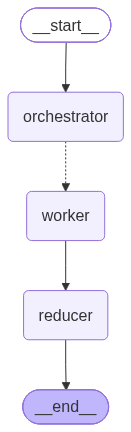

In [14]:
agent

In [15]:
out = agent.invoke({'topic' : 'The AI devlopement in the next 5 years'})

From the orchestrator node
From the fanout
======  From the 0 worker node   =====
======  From the 1 worker node   =====
======  From the 2 worker node   =====
======  From the 3 worker node   =====
======  From the 4 worker node   =====
======  From the 5 worker node   =====



==========  The 1 worker output ============


### Advancements in Machine Learning

As we look to the future of AI development, machine learning stands out as a key area of focus. In the next five years, we can expect significant advancements in machine learning that will transform the way we live and work.

**Current State and Limitations**

Currently, machine learning algorithms require large amounts of data to learn and improve. This can be a limitation in situations where data is scarce or difficult to obtain. Additionally, many machine learning models are designed to perform a specific task, and they may not generalize well to other tasks or domains.

**Potential Advancements**

In the next five years, we

In [18]:
out['final']

"# Revolutionizing the Future: AI Development in the Next 5 Years\n\n**Revolutionizing the Future: AI Development in the Next 5 Years**\n=====================================================================================\n\n### Introduction\n\nArtificial Intelligence (AI) has come a long way since its inception, transforming from a mere concept to a reality that is revolutionizing industries and transforming lives. As we stand at the threshold of a new decade, it is exciting to think about the immense potential that AI holds in shaping the future. In this article, we will delve into the current state of AI development, its applications, and the exciting developments that can be expected in the next 5 years.\n\n*   **The Growing Importance of AI**: AI is no longer a niche technology, but a mainstream phenomenon that is being adopted across various industries, including healthcare, finance, transportation, and education. Its ability to process vast amounts of data, learn from experienc

# Revolutionizing the Future: AI Development in the Next 5 Years

**Revolutionizing the Future: AI Development in the Next 5 Years**
=====================================================================================

### Introduction

Artificial Intelligence (AI) has come a long way since its inception, transforming from a mere concept to a reality that is revolutionizing industries and transforming lives. As we stand at the threshold of a new decade, it is exciting to think about the immense potential that AI holds in shaping the future. In this article, we will delve into the current state of AI development, its applications, and the exciting developments that can be expected in the next 5 years.

*   **The Growing Importance of AI**: AI is no longer a niche technology, but a mainstream phenomenon that is being adopted across various industries, including healthcare, finance, transportation, and education. Its ability to process vast amounts of data, learn from experiences, and make informed decisions has made it an indispensable tool for businesses and organizations.
*   **Current State of AI Development**: Today, AI is being used in a wide range of applications, from virtual assistants and chatbots to predictive analytics and machine learning algorithms. The development of AI has also led to the creation of new job roles and industries, such as AI engineering, data science, and robotics.
*   **Preview of Exciting Developments**: In the next 5 years, we can expect AI to become even more pervasive and sophisticated. Some of the exciting developments that can be expected include the widespread adoption of edge AI, the development of more advanced natural language processing (NLP) algorithms, and the increased use of AI in emerging technologies like augmented reality (AR) and virtual reality (VR).

### Advancements in Machine Learning

As we look to the future of AI development, machine learning stands out as a key area of focus. In the next five years, we can expect significant advancements in machine learning that will transform the way we live and work.

**Current State and Limitations**

Currently, machine learning algorithms require large amounts of data to learn and improve. This can be a limitation in situations where data is scarce or difficult to obtain. Additionally, many machine learning models are designed to perform a specific task, and they may not generalize well to other tasks or domains.

**Potential Advancements**

In the next five years, we can expect to see significant advancements in machine learning, including:

*   **Transfer Learning**: This involves training a model on one task and then fine-tuning it for another related task. This approach has shown great promise in reducing the amount of data required for training and improving the performance of models on new tasks.
*   **Few-Shot Learning**: This involves training a model on a small amount of data and then fine-tuning it for a new task. This approach has shown great promise in situations where data is scarce.

**Potential Applications**

The advancements in machine learning have the potential to transform a wide range of applications, including:

*   **Improved Natural Language Processing**: With the ability to learn from smaller amounts of data, machine learning models can be trained to understand and generate human language more effectively.
*   **Computer Vision**: The advancements in machine learning can be used to improve computer vision applications, such as image recognition and object detection.
*   **Autonomous Systems**: The advancements in machine learning can be used to improve the performance of autonomous systems, such as self-driving cars and drones.

### Rise of Edge AI
#### Revolutionizing Real-Time Processing and Decision Making

As AI continues to transform industries, a new paradigm is emerging: Edge AI. This innovative approach is poised to revolutionize the way we process and analyze data, enabling faster, more secure, and more efficient decision making.

#### What is Edge AI?

Edge AI refers to the deployment of AI algorithms and models at the edge of the network, i.e., on devices or nodes that are closer to the source of the data. This approach reduces latency, improves real-time processing, and enhances security by minimizing the amount of data transmitted to the cloud or central servers.

#### Current State of Edge AI

Edge AI is already being applied in various industries, including:

* **Smart Homes and Cities**: Edge AI-powered devices, such as smart thermostats and security cameras, can analyze data locally, reducing the need for cloud connectivity and improving response times.
* **Industrial Automation**: Edge AI can optimize manufacturing processes, predict maintenance needs, and improve product quality by analyzing data from sensors and machines.
* **Autonomous Vehicles**: Edge AI is used in self-driving cars to process sensor data, detect objects, and make decisions in real-time.

#### Future Developments in Edge AI

As 5G networks become more widespread, we can expect Edge AI to become even more pervasive. Some potential future developments include:

* **Integration with 5G Networks**: The high-speed, low-latency connectivity of 5G will enable more widespread adoption of Edge AI, particularly in applications that require real-time processing, such as autonomous vehicles and smart cities.
* **Increased Use of Specialized Hardware**: The development of specialized hardware, such as TPUs and GPUs, will accelerate Edge AI processing, enabling more complex models and applications.
* **Edge AI-powered IoT Devices**: The proliferation of IoT devices will drive the adoption of Edge AI, as more devices become capable of processing and analyzing data locally.

As Edge AI continues to evolve, we can expect to see significant improvements in industries that rely on real-time processing and decision making. With its potential to reduce latency, improve security, and enhance efficiency, Edge AI is poised to revolutionize the future of AI development.

### Increased Adoption of AI in Healthcare

The healthcare industry is on the cusp of a revolution, driven by the increasing adoption of Artificial Intelligence (AI). In the next five years, AI is expected to transform the way healthcare is delivered, making it more personalized, efficient, and effective.

#### Current State of AI in Healthcare

Currently, AI is being used in various applications in healthcare, including:

*   **Medical Imaging**: AI-powered algorithms are being used to analyze medical images, such as X-rays and MRIs, to help doctors diagnose diseases more accurately and quickly.
*   **Diagnosis**: AI-powered systems are being used to analyze patient data and medical histories to help doctors diagnose diseases more accurately.
*   **Clinical Decision Support**: AI-powered systems are being used to provide doctors with real-time, data-driven insights to inform their decision-making.

#### Future Developments in AI-Powered Healthcare

In the next five years, we can expect to see significant advancements in AI-powered healthcare, including:

*   **Personalized Medicine**: AI will be used to analyze individual patient data and develop personalized treatment plans.
*   **Predictive Analytics**: AI will be used to analyze large datasets and predict patient outcomes, allowing doctors to take proactive measures to prevent complications.
*   **Virtual Nursing Assistants**: AI-powered virtual nursing assistants will be used to provide patients with personalized care and support.

#### Benefits and Challenges of Increased AI Adoption

The increased adoption of AI in healthcare is expected to bring numerous benefits, including:

*   **Improved Patient Outcomes**: AI will help doctors diagnose diseases more accurately and quickly, leading to better patient outcomes.
*   **Increased Efficiency**: AI will help automate routine tasks, freeing up doctors to focus on more complex and high-value tasks.
*   **Reduced Costs**: AI will help reduce healthcare costs by reducing the need for unnecessary tests and procedures.

However, there are also challenges associated with the increased adoption of AI in healthcare, including:

*   **Data Quality and Integration**: AI requires high-quality and integrated data to function effectively, which can be a challenge in healthcare.
*   **Regulatory Frameworks**: There is a need for regulatory frameworks to ensure the safe and effective use of AI in healthcare.
*   **Cybersecurity**: AI-powered healthcare systems require robust cybersecurity measures to protect patient data.

Addressing AI Ethics and Bias
================================

As AI continues to revolutionize various aspects of our lives, it's essential to acknowledge the potential risks and challenges associated with its development. Two critical concerns that need to be addressed in the next 5 years are AI ethics and bias.

### Defining AI Ethics and Bias

AI ethics refers to the principles and values that guide the development and deployment of AI systems. It involves considering the potential consequences of AI on individuals, society, and the environment. AI bias, on the other hand, refers to the unfair or discriminatory outcomes that can result from AI systems. This can occur when AI algorithms are trained on biased data, leading to perpetuation of existing social inequalities.

### The Current State of AI Ethics and Bias

Currently, AI ethics and bias are significant challenges in the field of AI development. Many AI systems are designed and trained by homogeneous groups of people, which can lead to a lack of diversity in perspectives and experiences. This can result in AI systems that are not inclusive and perpetuate existing biases.

Some examples of AI bias include:

* Facial recognition systems that are less accurate for people with darker skin tones
* Natural language processing systems that are more likely to misinterpret language used by people from diverse backgrounds
* Recommendation systems that perpetuate existing social inequalities by suggesting products or services based on biased data

### Future Developments in AI Ethics and Bias

In the next 5 years, we can expect significant developments in addressing AI ethics and bias. Some potential advancements include:

* **More diverse and inclusive AI systems**: Efforts to increase diversity in AI development teams and training data can lead to more inclusive AI systems.
* **Explainable AI**: Techniques that provide insights into AI decision-making processes can help identify and address bias.
* **Fairness and transparency metrics**: Developing metrics to measure fairness and transparency in AI systems can help identify and mitigate bias.
* **Regulatory frameworks**: Governments and organizations may establish regulatory frameworks to ensure that AI systems are developed and deployed in a responsible and ethical manner.

By addressing AI ethics and bias, we can ensure that AI systems are developed and deployed in a way that benefits society as a whole.

### Revolutionizing the Future: AI Development in the Next 5 Years

#### Conclusion

As we conclude our exploration of the future of AI development, it's clear that the next 5 years will be transformative. We've discussed the potential advancements in **natural language processing**, **computer vision**, and **edge AI**, which will enable more sophisticated applications across industries. The integration of **quantum computing** and **explainable AI** will also be crucial in addressing current limitations and concerns.

The future of AI development holds immense promise, but it's essential to acknowledge the potential risks and challenges. As AI becomes increasingly pervasive, it's crucial that we prioritize **responsible AI development**, ensuring that these technologies benefit society as a whole. We must continue to invest in AI research, development, and education to unlock its full potential.

As we embark on this exciting journey, we encourage you to stay informed and engaged with the latest developments in AI. The possibilities are endless, and the impact on society will be profound. Join us in shaping the future of AI and exploring the incredible opportunities it presents.

In [16]:
out['final']

"# Revolutionizing the Future: AI Development in the Next 5 Years\n\n**Revolutionizing the Future: AI Development in the Next 5 Years**\n=====================================================================================\n\n### Introduction\n\nArtificial Intelligence (AI) has come a long way since its inception, transforming from a mere concept to a reality that is revolutionizing industries and transforming lives. As we stand at the threshold of a new decade, it is exciting to think about the immense potential that AI holds in shaping the future. In this article, we will delve into the current state of AI development, its applications, and the exciting developments that can be expected in the next 5 years.\n\n*   **The Growing Importance of AI**: AI is no longer a niche technology, but a mainstream phenomenon that is being adopted across various industries, including healthcare, finance, transportation, and education. Its ability to process vast amounts of data, learn from experienc

In [17]:
out

{'topic': 'The AI devlopement in the next 5 years',
 'plan': Plan(blog_title='Revolutionizing the Future: AI Development in the Next 5 Years', tasks=[Task(id=1, title='Introduction', goal='Provide an overview of the current state of AI development and its potential impact on various industries.', bullets=['Briefly introduce the concept of AI and its growing importance', 'Discuss the current state of AI development and its applications', 'Preview the exciting developments that can be expected in the next 5 years'], target_words=150, section_types='intro'), Task(id=2, title='Advancements in Machine Learning', goal='Explore the advancements in machine learning and their potential applications in the next 5 years.', bullets=['Discuss the current state of machine learning and its limitations', 'Explore the potential advancements in machine learning, such as transfer learning and few-shot learning', 'Discuss the potential applications of these advancements, such as improved natural language 

In [44]:
for key in out.keys():
    print(key , out[key])
    print('---------------------------------------------------------')

topic The AI devlopement in the next 5 years
---------------------------------------------------------
plan blog_title='The Next 5 Years of AI: Trends, Breakthroughs, and Real‑World Impact' tasks=[Task(id=1, title='Craft a compelling introduction', brief='Hook the reader, explain why a 5‑year outlook matters, and preview the main sections. Aim for 150‑200 words and embed primary SEO keywords (e.g., “future of AI”, “AI trends 2024‑2029”).'), Task(id=2, title='Section\u202f1 – “Foundations: What’s Changing Under the Hood?”', brief='Discuss the technical shifts that will drive AI forward (e.g., foundation models scaling, neuromorphic chips, hybrid symbolic‑neural systems, and new training paradigms such as self‑supervised and reinforcement‑learning‑at‑scale). Include 2‑3 concrete examples and a short “take‑away” box. Approx. 500‑600 words.'), Task(id=3, title='Section\u202f2 – “Generative AI Goes Mainstream”', brief='Cover the maturation of text‑to‑image/video/audio tools, multimodal assi

In [3]:
from langchain_core.messages import HumanMessage

In [4]:
var = [HumanMessage(content='I’m not sure what you’d like help with. Could you let me know what you need assistance with? Feel free to ask a question or describe the task you have in mind!', additional_kwargs={}, response_metadata={}, id='fde67dcb-630d-48f2-8315-36a2546a79d8'), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='04df72ce-c118-4d2c-8613-87d319bb2a59'), HumanMessage(content='Hello! 👋 How can I assist you today? Feel free to ask a question, describe a project, or let me know what you’d like to chat about.', additional_kwargs={}, response_metadata={}, id='f4a4dd51-4081-4ba9-8618-466992c69ed6')]

In [6]:
var[0].content

'I’m not sure what you’d like help with. Could you let me know what you need assistance with? Feel free to ask a question or describe the task you have in mind!'